<a href="https://colab.research.google.com/github/oliviaguo1234/money-market-funds/blob/main/money_market_funds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Cleaning/EDA

In [48]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats.contingency import association
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score, root_mean_squared_error

In [ ]:
url = "https://raw.githubusercontent.com/oliviaguo1234/money-market-funds/refs/heads/main/money-market-funds.csv"
df = pd.read_csv(url)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1206 entries, 0 to 1205
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ReportMonth          1206 non-null   object
 1   registrant_cik       1206 non-null   int64 
 2   registrant           1206 non-null   object
 3   series_name          1206 non-null   object
 4   series_id            1206 non-null   object
 5   series_category      1206 non-null   object
 6   class_name           1206 non-null   object
 7   class_id             1206 non-null   object
 8   investment_advisor   1206 non-null   object
 9   class_ticker_symbol  996 non-null    object
 10  sub_advisor          394 non-null    object
dtypes: int64(1), object(10)
memory usage: 103.8+ KB


In [ ]:
#remove null values from sub advisor; create boolean for if sub_advisor or not
print('Missing values in sub advisor:', df['sub_advisor'].isna().sum())
df['sub_advisor_clean'] = df['sub_advisor'].fillna('None')
df['has_sub_advisor'] = df['sub_advisor'].notnull()

#class_ticker_symbol: five-letter code ending in "XX" to identify mutual fund share class (diff class -> diff fees/commission)
print('Missing values in class ticker symbol:', df['class_ticker_symbol'].isna().sum())
df['class_ticker_symbol_clean'] = df['class_ticker_symbol'].fillna('Unlisted')
df['has_class_ticker_symbol'] = df['class_ticker_symbol'].notnull()

Missing values in sub advisor: 812
Missing values in class ticker symbol: 210


In [ ]:
#group the dataset by unique series using series_id
df['classes_per_series'] = df.groupby('series_id')['class_id'].transform('count')

#count how many funds each advisor oversees
df['advisor_total_series'] = df.groupby('investment_advisor')['series_id'].transform('count')

In [ ]:
#group advisors into 3 tiers
df['advisor_tier'] = pd.qcut(df['advisor_total_series'],
                             q = [0, 0.33, 0.66, 1.0],
                             labels = ['Tier 3 (Small-Sized)', 'Tier 2 (Medium-Sized)', 'Tier 1 (Large-Sized)'])

# HHI: Herfindahl-Hirschman Index

In [ ]:
#find Herfindahl-Hirschman Index (HHI)
advisor_counts = df['investment_advisor'].value_counts()
total_series = len(df)
shares = (advisor_counts / total_series) * 100

hhi_value = np.sum(shares ** 2)
print(hhi_value)
print('Unconcentrated: Competitive market, low market power, many small firms')

607.781985594416
Unconcentrated: Competitive market, low market power, many small firms


In [ ]:
#find concentration ratio: CR4 and CR8
sorted_shares = np.sort(shares)[::-1]
n_top = 4
concentration_ratio_top4 = np.sum(sorted_shares[:n_top])
print('CR4:', concentration_ratio_top4)

n_top = 8
concentration_ratio_top8 = np.sum(sorted_shares[:n_top])
print('CR8:', concentration_ratio_top8)

#top investment advisors by market share
print('Top 5 Investment Advisors by Market Share:')
print(shares.head(5))

CR4: 37.39635157545605
CR8: 56.6334991708126
Top 5 Investment Advisors by Market Share:
investment_advisor
Fidelity Management &amp; Research Company LLC    18.159204
Goldman Sachs Asset Management, L.P.               6.550580
J.P. Morgan Investment Management Inc.             6.467662
Morgan Stanley Investment Management, Inc.         6.218905
Federated Investment Management Company            6.053068
Name: count, dtype: float64


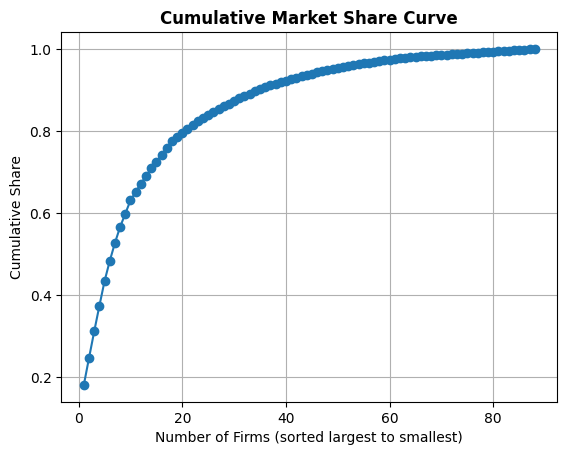

In [ ]:
#visualization of cumulative percentages curve
cum_shares = np.cumsum(sorted_shares)
cum_curve = cum_shares / cum_shares[-1]

plt.plot(np.arange(1, len(cum_curve) + 1), cum_curve, marker = 'o')
plt.title('Cumulative Market Share Curve', fontweight='bold')
plt.xlabel('Number of Firms (sorted largest to smallest)')
plt.ylabel('Cumulative Share')
plt.grid()
plt.show()

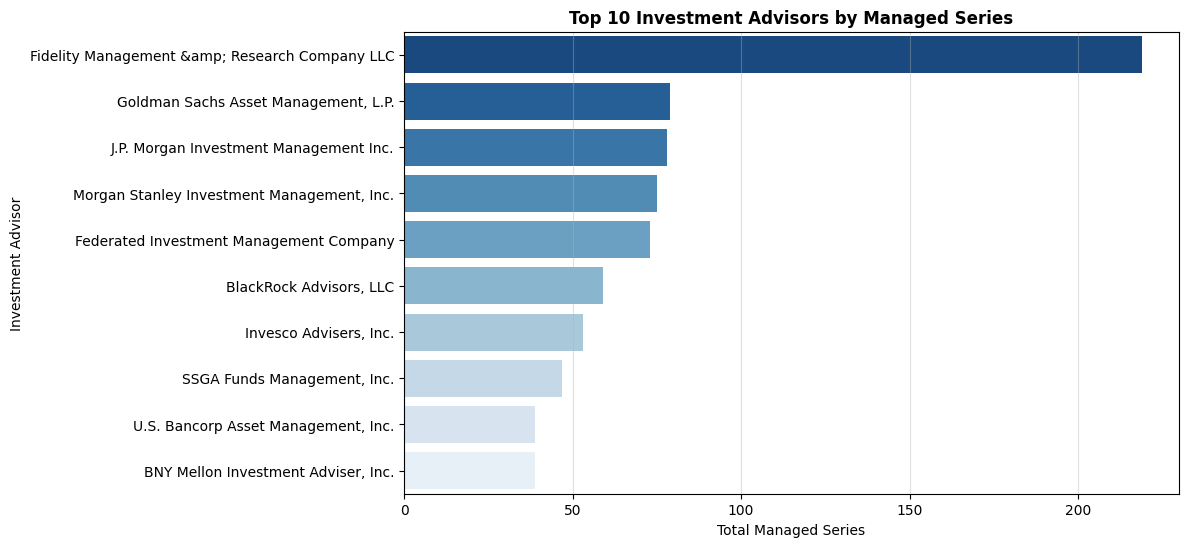

In [ ]:
#bar graph showing top investment advisors
plt.figure(figsize=(10,6))
top_10_advisors = advisor_counts.head(10)
sns.barplot(x=top_10_advisors.values, y=top_10_advisors.index, hue=top_10_advisors.index, palette='Blues_r', legend=False)

plt.xlabel('Total Managed Series')
plt.ylabel('Investment Advisor')
plt.title('Top 10 Investment Advisors by Managed Series', fontweight='bold')
plt.grid(axis='x', alpha=0.4)

plt.show()

# Calculate HHI per Fund Category

In [ ]:
#calculate HHI within each fund category
def calculate_hhi(group):
  shares = (group['investment_advisor'].value_counts() / len(group)) * 100
  return np.sum(shares ** 2)

category_hhi = df.groupby('series_category').apply(calculate_hhi, include_groups=False)

print('HHI Index per Fund Category:')
for category, hhi_val in category_hhi.items():
  if hhi_val > 2500:
    status = 'Highly Concentrated'
  elif hhi_val >= 1500:
    status = 'Moderately Concentrated'
  else:
    status = 'Unconcentrated'

  print(category + ' HHI:', str(round(hhi_val, 2)) + ' (' + status + ')')

HHI Index per Fund Category:
Government HHI: 454.27 (Unconcentrated)
Other Tax Exempt HHI: 1768.55 (Moderately Concentrated)
Prime HHI: 797.66 (Unconcentrated)
Single State HHI: 2885.33 (Highly Concentrated)


# Hypothesis Tests

In [ ]:
#null hypothesis (H0) = an asset manager's tier (advisor_tier) does not have an influence on the types of funds (series_category)
#alternative hypothesis (Ha) = asset manager's tier (advisor_tier) has an influence on the types of funds (series_category)
con_table = pd.crosstab(df['advisor_tier'], df['series_category'])
print(con_table)

result = stats.chi2_contingency(con_table)
chi2_state = result.statistic
p_val = result.pvalue
expected_table = result.expected_freq

print(expected_table)
print('P-value:', p_val)
if p_val < 0.05:
  print('P-value is significant; reject null hypothesis')

series_category        Government  Other Tax Exempt  Prime  Single State
advisor_tier                                                            
Tier 3 (Small-Sized)          358                16     37             9
Tier 2 (Medium-Sized)         298                30     73             9
Tier 1 (Large-Sized)          213                56     50            57
[[302.63681592  35.52238806  55.72139303  26.11940299]
 [295.43117745  34.67661692  54.3946932   25.49751244]
 [270.93200663  31.80099502  49.88391376  23.38308458]]
P-value: 1.0362147297553558e-26
P-value is significant; reject null hypothesis


In [ ]:
#ANOVA to test if classes_per_series differ across series_category
gov = df[df['series_category'] == 'Government']['classes_per_series']
prime = df[df['series_category'] == 'Prime']['classes_per_series']
tax_exempt = df[df['series_category'] == 'Other Tax Exempt']['classes_per_series']
single_state = df[df['series_category'] == 'Single State']['classes_per_series']
results = stats.f_oneway(gov, prime, tax_exempt, single_state)
p_val = results.pvalue

print("F Statistic:", results.statistic)
print("P-Value:", p_val)

if p_val < 0.05:
    print("Result: Statistically Significant, classes per series differ across different series.")
else:
    print("Result: Not Statistically Significant.")

F Statistic: 6.186822198352626
P-Value: 0.00035920253969810406
Result: Statistically Significant, classes per series differ across different series.


In [ ]:
#tukey's hsd
tukey = pairwise_tukeyhsd(endog=df['classes_per_series'], groups = df['series_category'])
print(tukey)
print(tukey.pvalues)

          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1           group2      meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------
      Government Other Tax Exempt  -1.5492 0.0235 -2.9509 -0.1476   True
      Government            Prime  -1.4022 0.0096 -2.5542 -0.2501   True
      Government     Single State  -1.3555 0.1341 -2.9672  0.2562  False
Other Tax Exempt            Prime   0.1471 0.9961 -1.5497  1.8438  False
Other Tax Exempt     Single State   0.1937 0.9949 -1.8433  2.2307  False
           Prime     Single State   0.0467 0.9999 -1.8274  1.9207  False
------------------------------------------------------------------------
[0.02346694 0.00963822 0.13406113 0.99608983 0.99485319 0.99990566]


**Observations**
- Statistically significant difference between government vs other tax exempt and government vs prime
- Government funds have fewer share classes on average compared to Prime and Other Tax Exempt funds

In [ ]:
#use Kruskal-Wallis H Test to support ANOVA
h_stat, p_val = stats.kruskal(gov, prime, tax_exempt, single_state)

print("H-Statistic:", str(h_stat))
print("P-Value:", str(p_val))

H-Statistic: 6.637149750490608
P-Value: 0.0844077793340357


- ANOVA was statistically significant, while Kruskal-Wallis H Test was not
- While median class counts remain relatively uniform across categories, there are certain share classes heavily concentrated within specific fund types

In [ ]:
#use chi-squared test to determine if Advisor Tier impacts the likelihood of having a sub_advisor
#null hypothesis (H0): Sub_advisor usage is independent from advisor's tier
#alternative hypothesis (Ha): Sub_advisor usage depends on advisor's tier size
sub_table = pd.crosstab(df['advisor_tier'], df['has_sub_advisor'])

chi2, p_val_sub, dof, expected = stats.chi2_contingency(sub_table)

print('Chi2:', str(chi2))
print('P-value:', str(p_val_sub))

Chi2: 220.44477749206726
P-value: 1.3521497288511738e-48


**Observations**
- P-value is statistically significant. Therefore, having a sub advisor depends on the advisor's tier size.
- --> investigate which tiers (Tier 1, Tier 2, Tier 3) tend to have more sub advisors using Cramer's V to determine strength of correlation and standardized residuals to see the specific subgroups drive the difference

In [ ]:
#Standardized residuals
standard_residuals = (sub_table - expected) / np.sqrt(expected)
print('Standardized Residuals:')
print(standard_residuals)

#Cramer's V
obs = sub_table.to_numpy()

cramers_v = association(obs, method='cramer')
print("Cramer's V:", str(cramers_v))

Standardized Residuals:
has_sub_advisor           False     True 
advisor_tier                             
Tier 3 (Small-Sized)  -0.165677  0.237844
Tier 2 (Medium-Sized)  5.955333 -8.549406
Tier 1 (Large-Sized)  -6.043661  8.676208
Cramer's V: 0.4275395082187723


**Observations**
- Standardized residuals for Tier 1 were 8.68 (True) and -6.04 (False), representing how they use sub-advisors far more than expected by chance, likely for specialization to be able to handle funds with specific, specialized asset strategies.
- Standardized residuals for Tier 2 were -8.55 (True) and 5.96 (False), representing how Tier 2 firms used sub-advisors far less than expected by chance, likely due to a preference to keep investment tasks in-house to save money with only a medium-sized team.
- Standardized residuals for Tier 3 were 0.24 (True) and -0.17 (False), which matched expectations almost perfectly (baseline = 0).
- Cramer's V has a value of ~0.43, which shows strong/large correlation.

In [ ]:
#Mann-Whitney U Test
with_ticker = df[df['has_class_ticker_symbol'] == 1]['classes_per_series']
no_ticker = df[df['has_class_ticker_symbol'] == 0]['classes_per_series']

statistic, p_value = stats.mannwhitneyu(with_ticker, no_ticker, alternative='two-sided')

print('U-Statistic:', str(statistic))
print('P-value:', str(p_value))

U-Statistic: 136980.5
P-value: 1.391661831404094e-12


**Observations**
- P-value is statistically significant.

# Machine Learning Model

In [ ]:
#machine learning model: random forest classifier
features = df[['has_sub_advisor', 'has_class_ticker_symbol', 'classes_per_series', 'advisor_tier']]
label = df['series_category']
features_encoded = pd.get_dummies(features, columns = ['advisor_tier'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(features_encoded, label, test_size=0.2, stratify=label)
model = RandomForestClassifier(
    n_estimators = 100,
    class_weight = 'balanced',
    random_state = 42
)
model.fit(X_train, y_train)
pred = model.predict(X_test)

In [ ]:
#evaluate machine learning model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print('Model Accuracy:', accuracy)
classification = classification_report(y_test, y_pred)
print(classification)

Model Accuracy: 0.6694214876033058
                  precision    recall  f1-score   support

      Government       0.97      0.65      0.78       174
Other Tax Exempt       0.34      0.67      0.45        21
           Prime       0.43      0.62      0.51        32
    Single State       0.39      1.00      0.57        15

        accuracy                           0.67       242
       macro avg       0.53      0.74      0.58       242
    weighted avg       0.81      0.67      0.70       242



#Visualizations

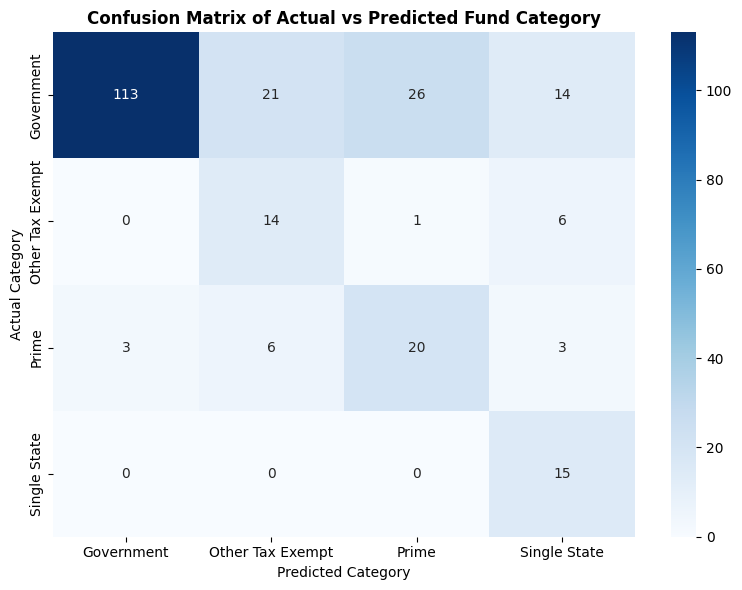

In [ ]:
#create confusion matrix for random forest classifier
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)

plt.title('Confusion Matrix of Actual vs Predicted Fund Category', fontweight='bold')
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')

plt.tight_layout()
plt.show()

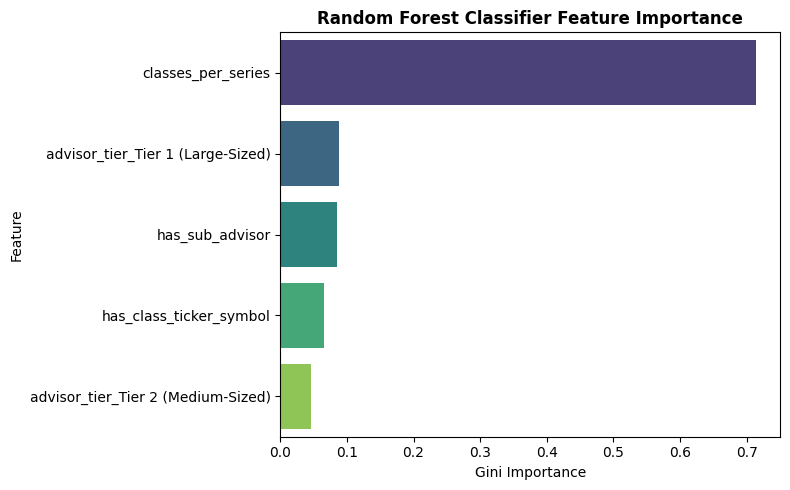

                              Feature  Importance
2                  classes_per_series    0.714379
4   advisor_tier_Tier 1 (Large-Sized)    0.087869
0                     has_sub_advisor    0.085246
1             has_class_ticker_symbol    0.066037
3  advisor_tier_Tier 2 (Medium-Sized)    0.046469


In [ ]:
#bar graph showing feature importance
importance_df = pd.DataFrame({
    'Feature': features_encoded.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=importance_df,
    x='Importance', y='Feature',
    hue='Feature',
    palette='viridis',
    legend=False
)

plt.title('Random Forest Classifier Feature Importance', fontweight='bold')
plt.xlabel('Gini Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

print(importance_df)

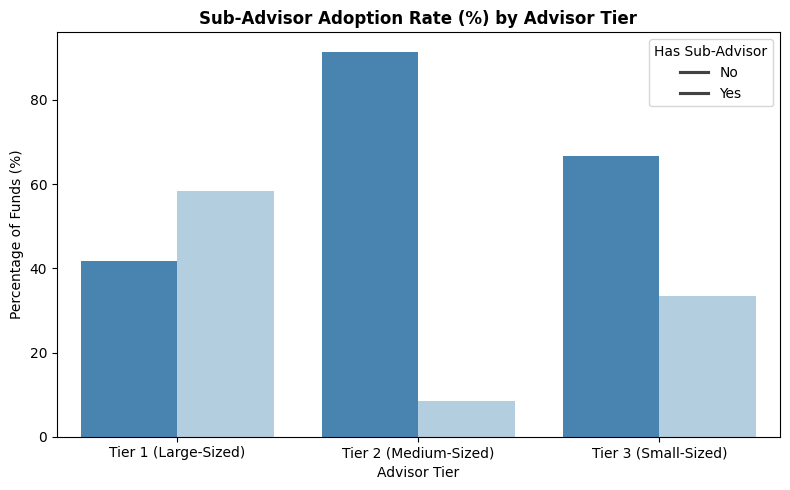

In [ ]:
#seaborn bar plot showing sub-advisor usage by advisor tier
tier_advisor_percent = (
    df.groupby('advisor_tier', observed=False)['has_sub_advisor']
    .value_counts(normalize = True).rename('percentage')
    .reset_index()
)
tier_advisor_percent['percentage'] = tier_advisor_percent['percentage'] * 100

plt.figure(figsize=(8, 5))
sns.barplot(
    data = tier_advisor_percent,
    x = 'advisor_tier',
    y = 'percentage',
    hue = 'has_sub_advisor',
    palette = 'Blues_r',
    order = ['Tier 1 (Large-Sized)', 'Tier 2 (Medium-Sized)', 'Tier 3 (Small-Sized)']
)

plt.title('Sub-Advisor Adoption Rate (%) by Advisor Tier', fontweight='bold')
plt.xlabel('Advisor Tier')
plt.ylabel('Percentage of Funds (%)')
plt.legend(title = 'Has Sub-Advisor', labels = ['No', 'Yes'])

plt.tight_layout()
plt.show()

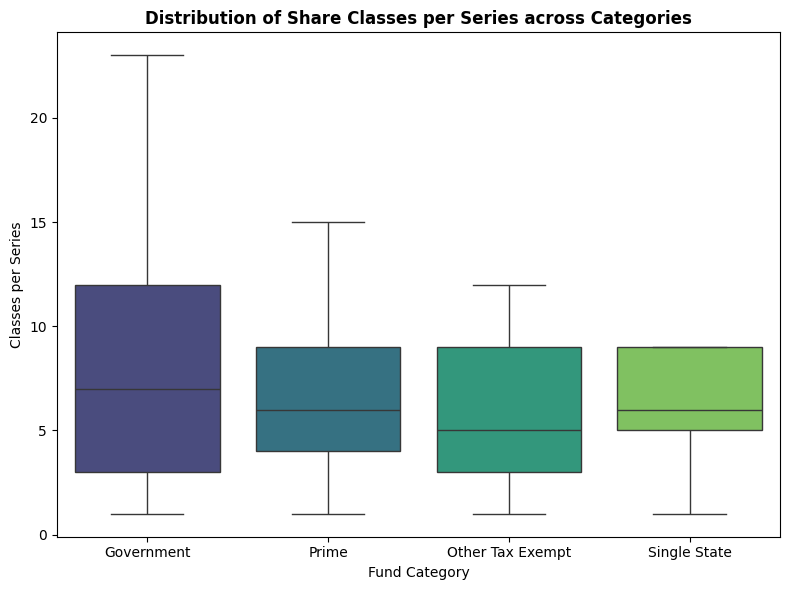

In [ ]:
#box plot showing share classes per series across different categories
plt.figure(figsize = (8, 6))
sns.boxplot(
    data = df,
    x = 'series_category',
    y = 'classes_per_series',
    hue = 'series_category',
    palette = 'viridis',
    showfliers = True,
    legend=False
)

plt.title('Distribution of Share Classes per Series across Categories', fontweight='bold')
plt.xlabel('Fund Category')
plt.ylabel('Classes per Series')

plt.tight_layout()
plt.show()

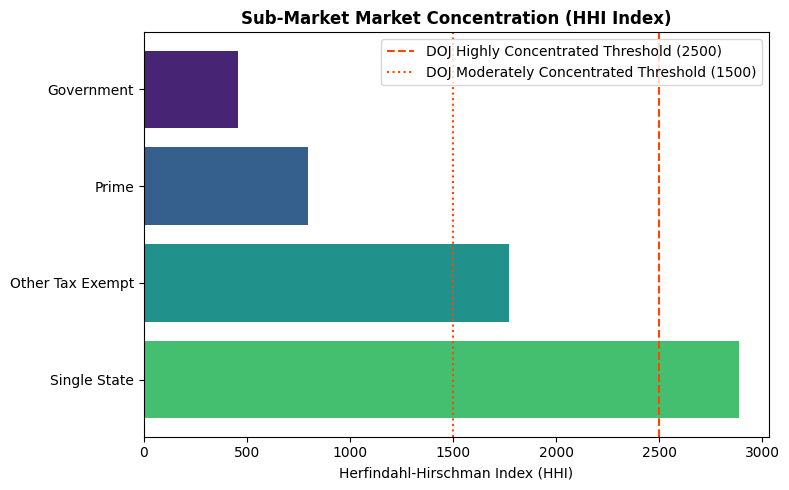

In [ ]:
#bar plot comparing different fund market concentrations
hhi_data = pd.DataFrame({
    'Category': ['Single State', 'Other Tax Exempt', 'Prime', 'Government'],
    'HHI': [2885.33, 1768.55, 797.66, 454.27]
})

plt.figure(figsize=(8, 5))

cmap = plt.get_cmap('viridis')
color1 = cmap(0.7)
color2 = cmap(0.5)
color3 = cmap(0.3)
color4 = cmap(0.1)
colors = [color1, color2, color3, color4]

bars = plt.barh(hhi_data['Category'], hhi_data['HHI'], color = colors)
plt.axvline(x=2500, color='#ff4500', linestyle='--', linewidth=1.5, label='DOJ Highly Concentrated Threshold (2500)')
plt.axvline(x=1500, color='#ff4500', linestyle=':', linewidth=1.5, label='DOJ Moderately Concentrated Threshold (1500)')

plt.title('Sub-Market Market Concentration (HHI Index)', fontweight='bold')
plt.xlabel('Herfindahl-Hirschman Index (HHI)')
plt.legend(loc='upper right')

#loc='best'

plt.tight_layout()
plt.show()

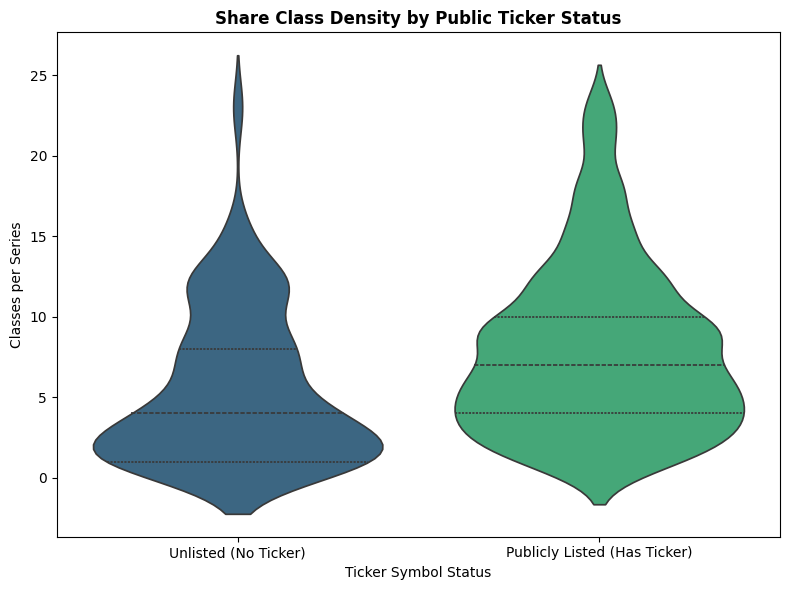

In [ ]:
#violin plot showing how funds with ticker symbols have unique share class distribution
plt.figure(figsize = (8, 6))
sns.violinplot(
    data = df,
    x = 'has_class_ticker_symbol',
    y = 'classes_per_series',
    hue = 'has_class_ticker_symbol',
    palette = 'viridis',
    inner = 'quartile',
    legend = False
)

plt.xticks(ticks = [0, 1], labels = ['Unlisted (No Ticker)', 'Publicly Listed (Has Ticker)'])

plt.title('Share Class Density by Public Ticker Status', fontweight='bold')
plt.xlabel('Ticker Symbol Status')
plt.ylabel('Classes per Series')

plt.tight_layout()
plt.show()